# Credit Risk Classification

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Loading the dataset:

In [2]:
file_name = "Credit Risk.csv"
df_credit_risk = pd.read_csv(file_name)
df_credit_risk

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


Performing Exploratory Data Analysis (EDA) on a dataset:

In [3]:
df_credit_risk.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df_credit_risk.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
df_credit_risk.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df_credit_risk = df_credit_risk.drop(columns=["Loan_ID"], errors="ignore")
df_credit_risk

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


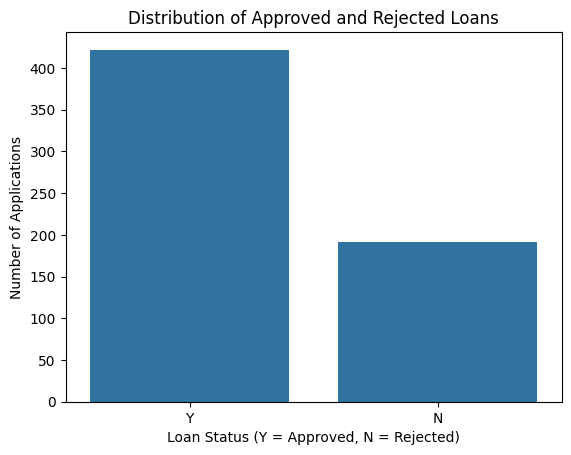

In [7]:
sns.countplot(data=df_credit_risk, x="Loan_Status")
plt.title("Distribution of Approved and Rejected Loans")
plt.xlabel("Loan Status (Y = Approved, N = Rejected)")
plt.ylabel("Number of Applications")
plt.show()

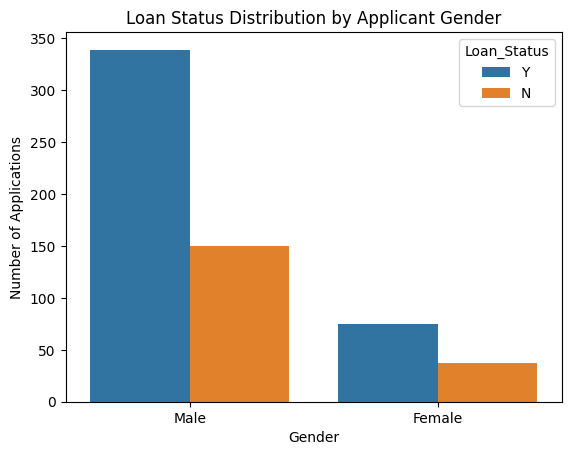

In [8]:
sns.countplot(data=df_credit_risk, x="Gender", hue="Loan_Status")
plt.title("Loan Status Distribution by Applicant Gender")
plt.ylabel("Number of Applications")
plt.show()

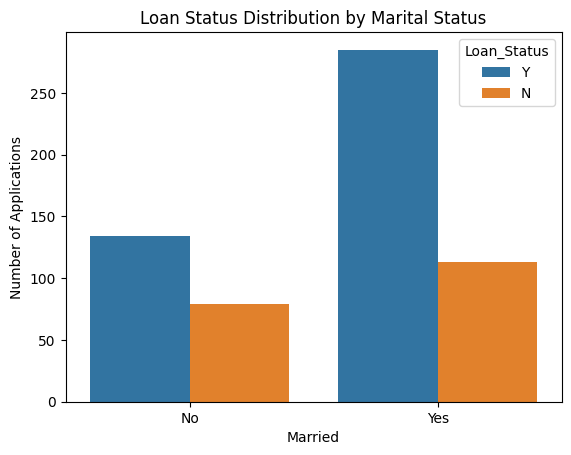

In [9]:
sns.countplot(data=df_credit_risk, x="Married", hue="Loan_Status")
plt.title("Loan Status Distribution by Marital Status")
plt.ylabel("Number of Applications")
plt.show()

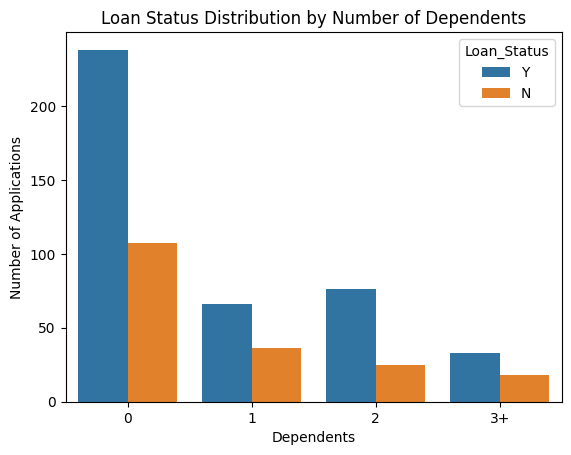

In [10]:
sns.countplot(data=df_credit_risk, x="Dependents", hue="Loan_Status")
plt.title("Loan Status Distribution by Number of Dependents")
plt.ylabel("Number of Applications")
plt.show()

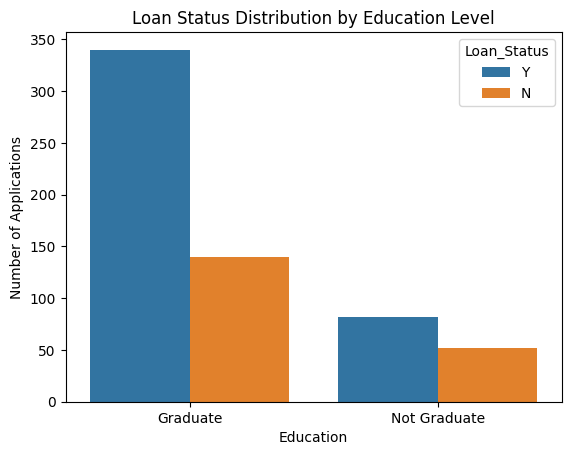

In [11]:
sns.countplot(data=df_credit_risk, x="Education", hue="Loan_Status")
plt.title("Loan Status Distribution by Education Level")
plt.ylabel("Number of Applications")
plt.show()

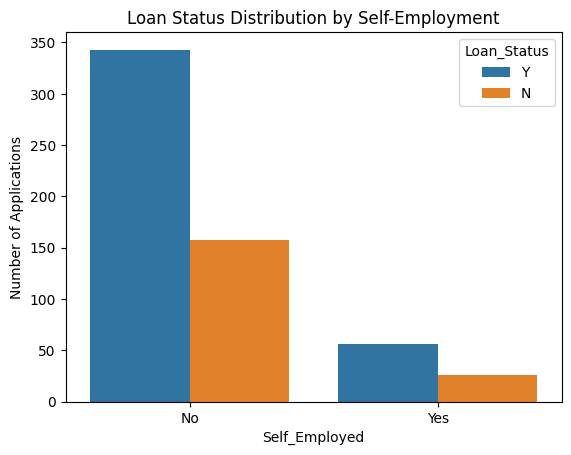

In [12]:
sns.countplot(data=df_credit_risk, x="Self_Employed", hue="Loan_Status")
plt.title("Loan Status Distribution by Self-Employment")
plt.ylabel("Number of Applications")
plt.show()

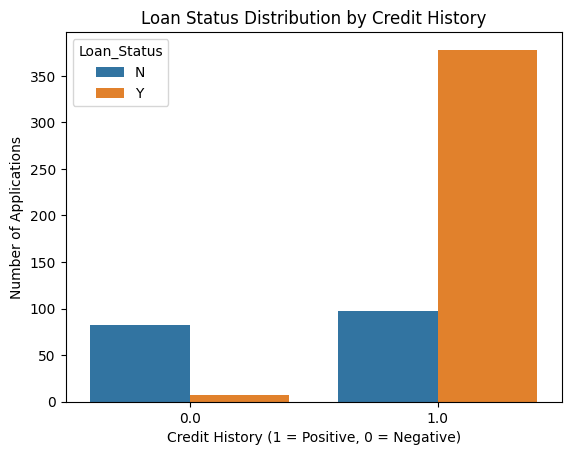

In [13]:
sns.countplot(data=df_credit_risk, x="Credit_History", hue="Loan_Status")
plt.title("Loan Status Distribution by Credit History")
plt.xlabel("Credit History (1 = Positive, 0 = Negative)")
plt.ylabel("Number of Applications")
plt.show()

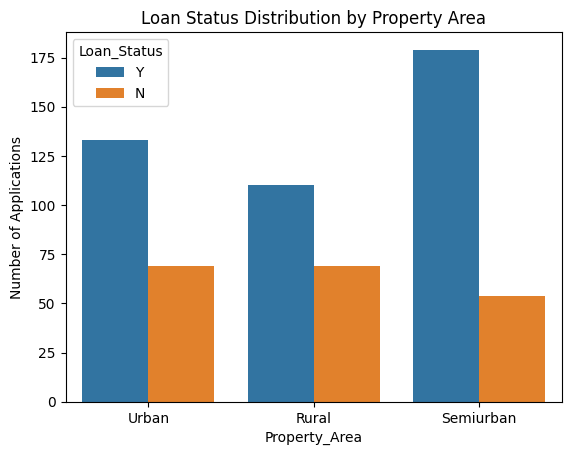

In [14]:
sns.countplot(data=df_credit_risk, x="Property_Area", hue="Loan_Status")
plt.title("Loan Status Distribution by Property Area")
plt.ylabel("Number of Applications")
plt.show()

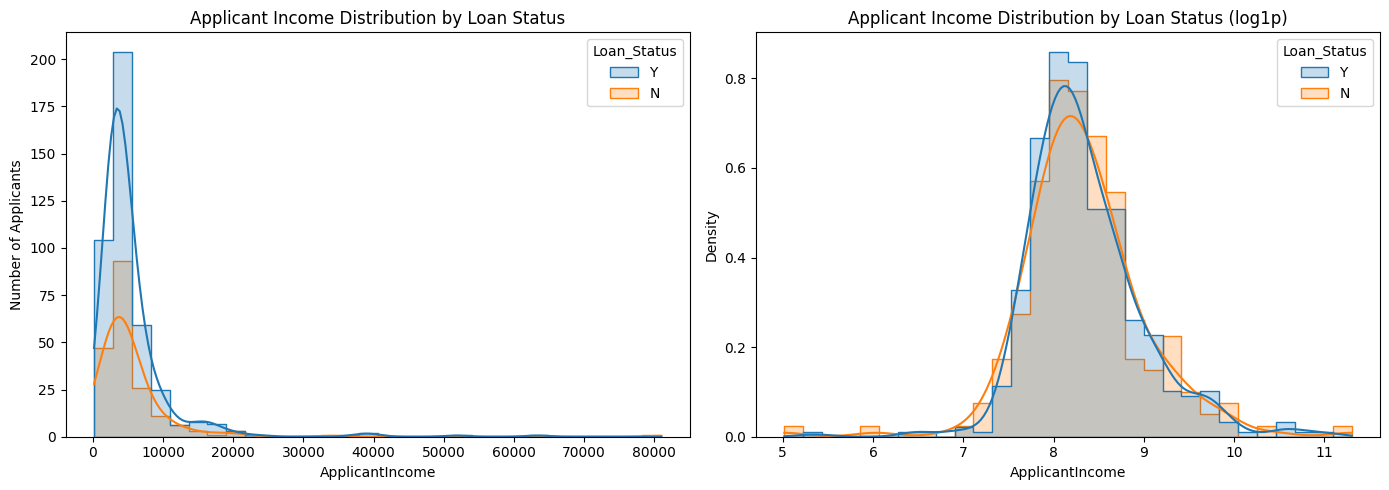

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(data=df_credit_risk, x="ApplicantIncome", hue="Loan_Status", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Applicant Income Distribution by Loan Status")
axes[0].set_ylabel("Number of Applicants")

sns.histplot(data=df_credit_risk, x=np.log1p(df_credit_risk["ApplicantIncome"]), hue="Loan_Status", bins=30, kde=True, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Applicant Income Distribution by Loan Status (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

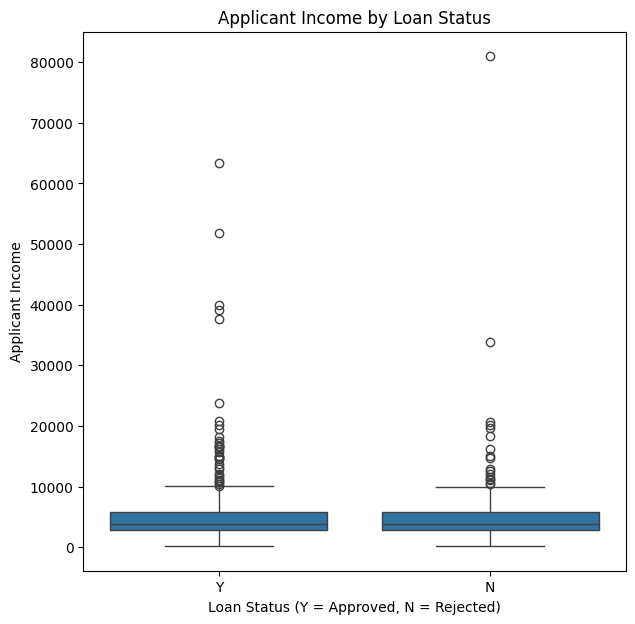

In [16]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df_credit_risk, x="Loan_Status", y="ApplicantIncome")
plt.title("Applicant Income by Loan Status")
plt.xlabel("Loan Status (Y = Approved, N = Rejected)")
plt.ylabel("Applicant Income")
plt.show()

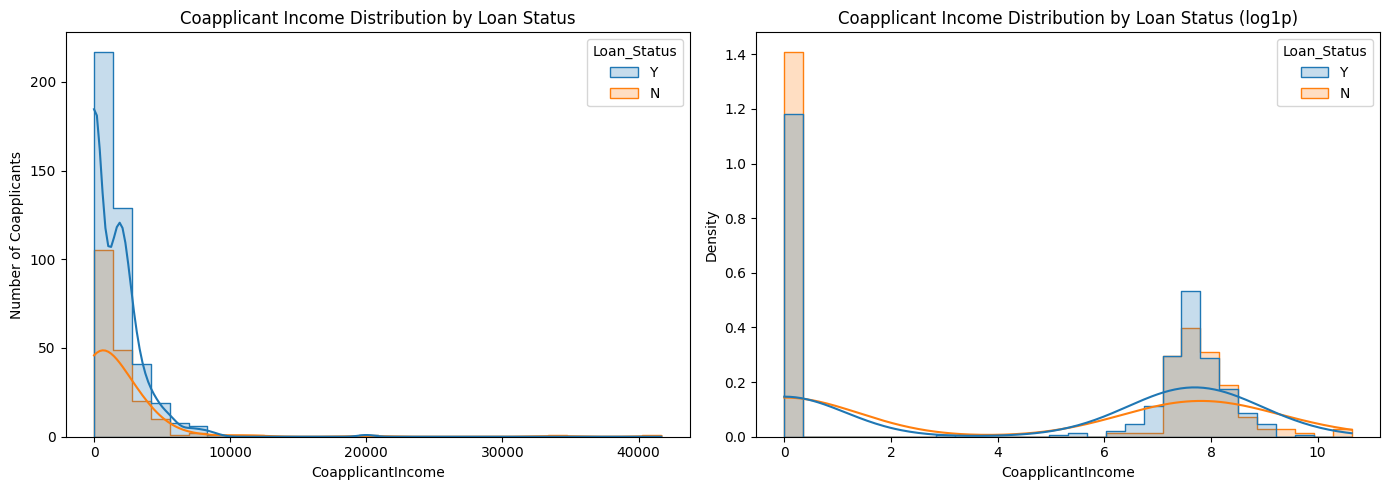

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(data=df_credit_risk, x="CoapplicantIncome", hue="Loan_Status", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Coapplicant Income Distribution by Loan Status")
axes[0].set_ylabel("Number of Coapplicants")

sns.histplot(data=df_credit_risk, x=np.log1p(df_credit_risk["CoapplicantIncome"]), hue="Loan_Status", bins=30, kde=True, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Coapplicant Income Distribution by Loan Status (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

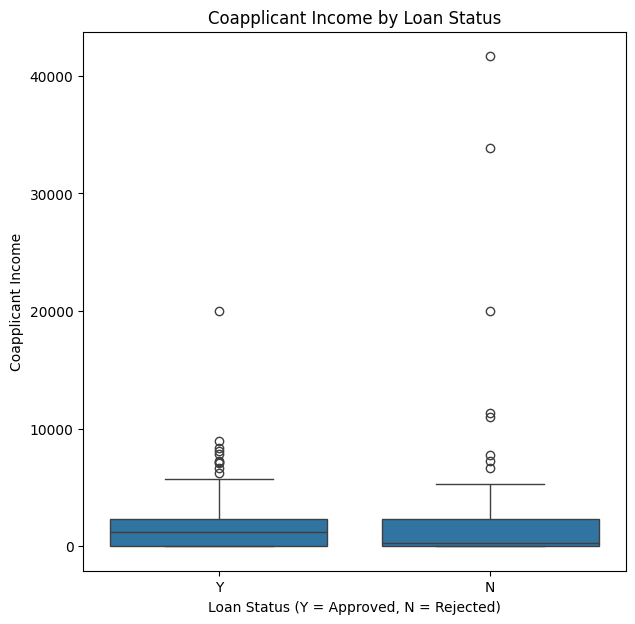

In [18]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df_credit_risk, x="Loan_Status", y="CoapplicantIncome")
plt.title("Coapplicant Income by Loan Status")
plt.xlabel("Loan Status (Y = Approved, N = Rejected)")
plt.ylabel("Coapplicant Income")
plt.show()

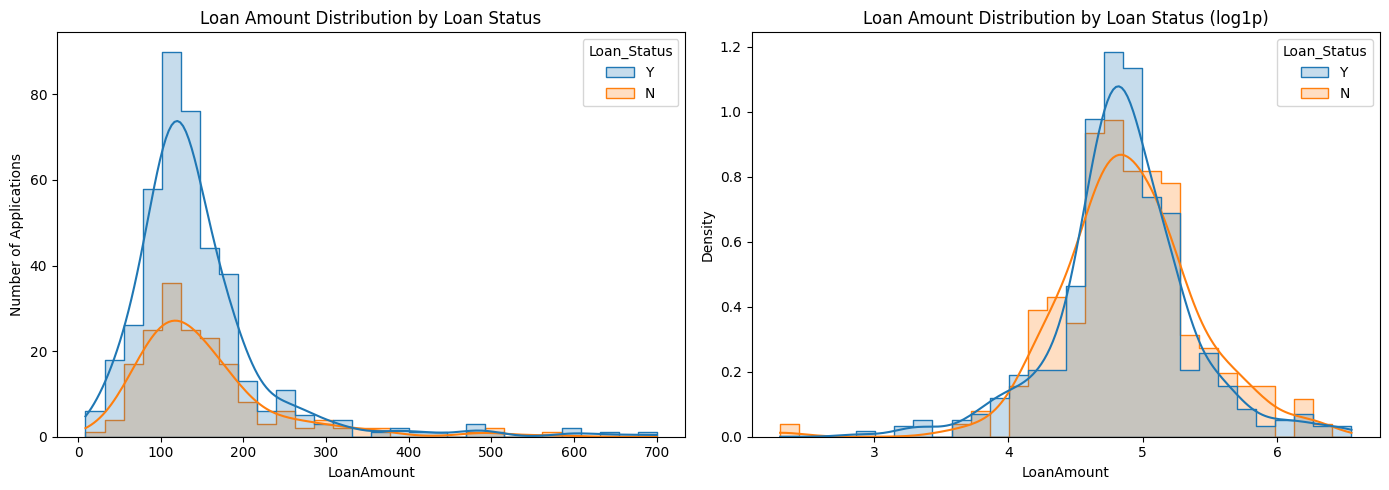

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(data=df_credit_risk, x="LoanAmount", hue="Loan_Status", bins=30, kde=True, element="step", ax=axes[0])
axes[0].set_title("Loan Amount Distribution by Loan Status")
axes[0].set_ylabel("Number of Applications")

sns.histplot(data=df_credit_risk, x=np.log1p(df_credit_risk["LoanAmount"]), hue="Loan_Status", bins=30, kde=True, element="step", stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Loan Amount Distribution by Loan Status (log1p)")
axes[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

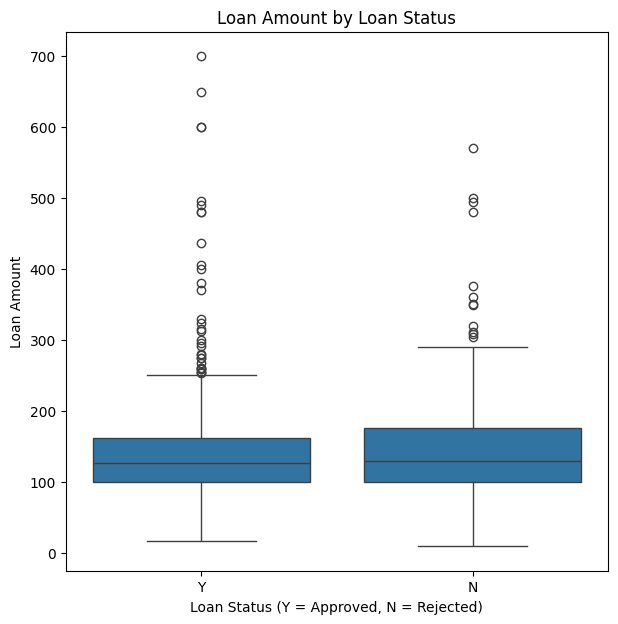

In [20]:
plt.figure(figsize=(7,7))
sns.boxplot(data=df_credit_risk, x="Loan_Status", y="LoanAmount")
plt.title("Loan Amount by Loan Status")
plt.xlabel("Loan Status (Y = Approved, N = Rejected)")
plt.ylabel("Loan Amount")
plt.show()

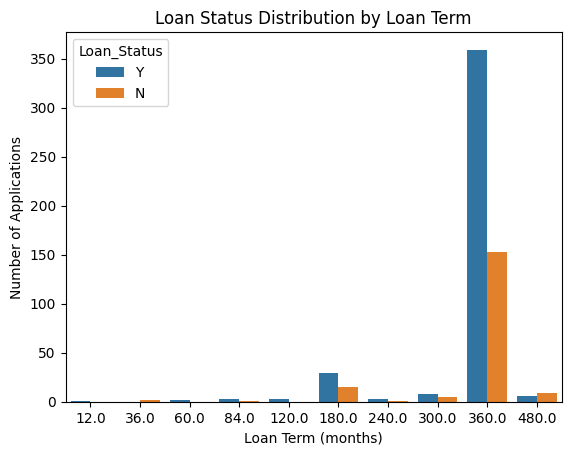

In [21]:
sns.countplot(data=df_credit_risk, x="Loan_Amount_Term", hue="Loan_Status")
plt.title("Loan Status Distribution by Loan Term")
plt.xlabel("Loan Term (months)")
plt.ylabel("Number of Applications")
plt.show()

In [22]:
df_credit_risk["Loan_Status"] = df_credit_risk["Loan_Status"].map({"Y": 1, "N": 0})

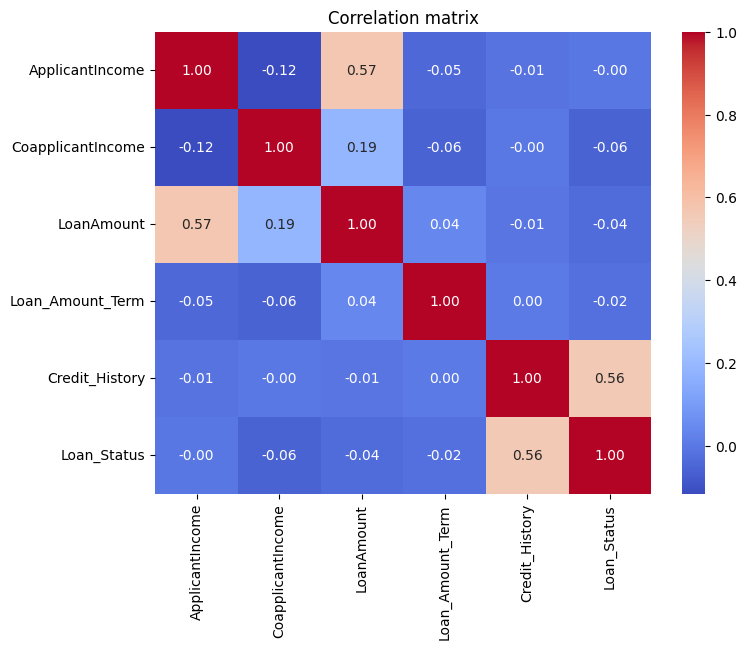

In [23]:
plt.figure(figsize=(8,6))
sns.heatmap(df_credit_risk.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

Implementation of a training and evaluation function for the credit risk classification task:

In [29]:
def classification_experiment(df, model_name="Logistic Regression"):

    data = df.copy()

    X = data.drop(columns=["Loan_Status"])
    y = data["Loan_Status"]

    num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
    num_transformer_temp = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    X_num_scaled = num_transformer_temp.fit_transform(X[num_features])

    iso = IsolationForest(contamination=0.05, random_state=42)
    yhat = iso.fit_predict(X_num_scaled)
    mask = yhat != -1
    print(f"Removed {np.sum(~mask)} outliers from {len(X)} records.")

    X_clean = X.loc[mask].reset_index(drop=True)
    y_clean = y.loc[mask].reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X_clean, y_clean, test_size=0.2, stratify=y_clean, random_state=42
    )

    num_features = X_clean.select_dtypes(include=["int64", "float64"]).columns.tolist()
    cat_features = X_clean.select_dtypes(include=["object"]).columns.tolist()

    num_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", num_transformer, num_features),
        ("cat", cat_transformer, cat_features)
    ])

    models = {
        "Logistic Regression": LogisticRegression(max_iter=500, random_state=42, class_weight="balanced"),
        "Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
        "KNN": KNeighborsClassifier()
    }
    model = models[model_name]

    param_grids = {
        "Logistic Regression": {"model__C": np.logspace(-2, 2, 10)},
        "Decision Tree": {"model__max_depth": list(range(2, 21, 2))},
        "KNN": {"model__n_neighbors": list(range(3, 30, 2))},
        "Naive Bayes": {}
    }
    param_grid = param_grids[model_name]

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    grid_search = GridSearchCV(pipeline, param_grid=param_grid, cv=5, scoring="balanced_accuracy", n_jobs=-1)
    grid_search.fit(X_train, y_train)

    print(f"\n===== {model_name} =====")
    print("Best parameters:", grid_search.best_params_ if param_grid else "Default parameters were used")

    y_pred = grid_search.predict(X_test)
    print("\nEvaluation on the test set:")
    print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))
    
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm).plot(cmap="Blues")
    plt.title(f"{model_name}: Confusion Matrix")
    plt.show()

    return grid_search

Logistic Regression experiment:

Removed 31 outliers from 614 records.

===== Logistic Regression =====
Best parameters: {'model__C': np.float64(0.01)}

Evaluation on the test set:
              precision    recall  f1-score   support

    Rejected       0.83      0.57      0.68        35
    Approved       0.84      0.95      0.89        82

    accuracy                           0.84       117
   macro avg       0.84      0.76      0.78       117
weighted avg       0.84      0.84      0.83       117



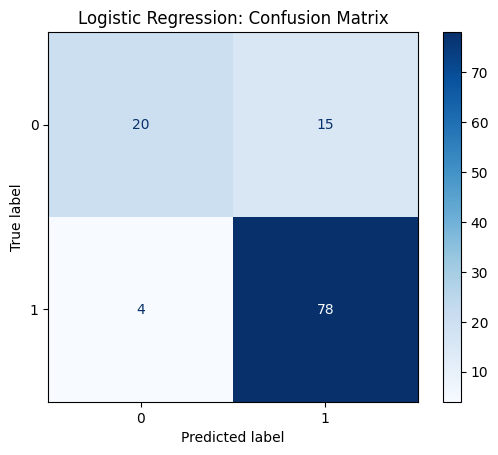

,estimator,Pipeline(step...m_state=42))])
,param_grid,{'model__C': array([1.0000...00000000e+02])}
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [30]:
classification_experiment(df_credit_risk, model_name="Logistic Regression")

Naive Bayes experiment:

Removed 31 outliers from 614 records.

===== Naive Bayes =====
Best parameters: Default parameters were used

Evaluation on the test set:
              precision    recall  f1-score   support

    Rejected       0.86      0.54      0.67        35
    Approved       0.83      0.96      0.89        82

    accuracy                           0.84       117
   macro avg       0.85      0.75      0.78       117
weighted avg       0.84      0.84      0.83       117



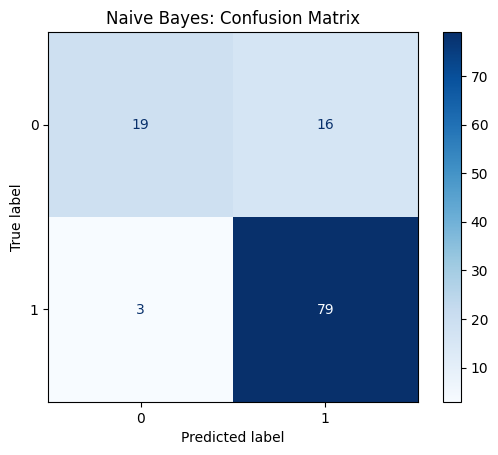

,estimator,Pipeline(step...aussianNB())])
,param_grid,{}
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [31]:
classification_experiment(df_credit_risk, model_name="Naive Bayes")

Decision Tree experiment:

Removed 31 outliers from 614 records.

===== Decision Tree =====
Best parameters: {'model__max_depth': 2}

Evaluation on the test set:
              precision    recall  f1-score   support

    Rejected       0.86      0.54      0.67        35
    Approved       0.83      0.96      0.89        82

    accuracy                           0.84       117
   macro avg       0.85      0.75      0.78       117
weighted avg       0.84      0.84      0.83       117



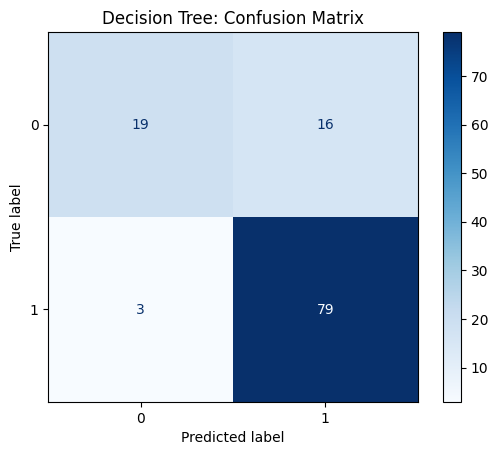

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [2, 4, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [32]:
classification_experiment(df_credit_risk, model_name="Decision Tree")

KNN experiment:

Removed 31 outliers from 614 records.

===== KNN =====
Best parameters: {'model__n_neighbors': 5}

Evaluation on the test set:
              precision    recall  f1-score   support

    Rejected       0.74      0.57      0.65        35
    Approved       0.83      0.91      0.87        82

    accuracy                           0.81       117
   macro avg       0.79      0.74      0.76       117
weighted avg       0.81      0.81      0.80       117



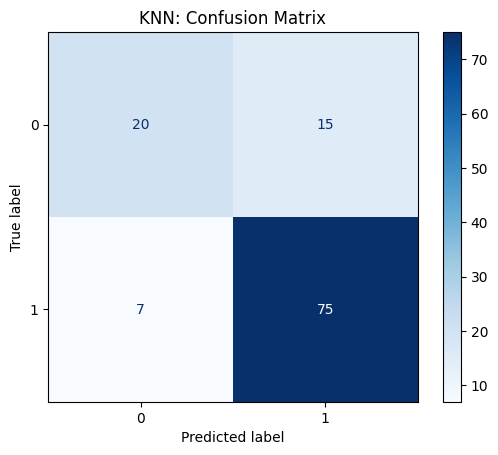

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__n_neighbors': [3, 5, ...]}"
,scoring,'balanced_accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [33]:
classification_experiment(df_credit_risk, model_name="KNN")

##### Model performance comparison:
Based on the obtained results, it can be concluded that all evaluated algorithms achieved a similar level of accuracy (0.81 and 0.84). However, they differ in their decision-making behavior.

Logistic Regression demonstrated a tendency to predict the positive class ("Approved") more frequently, as indicated by the considerably higher Recall for the "Approved" class (0.95) compared to the "Rejected" class (0.57). At the same time, similar Precision values for both classes (0.83 and 0.84) indicate consistent prediction quality and the absence of significant bias in prediction accuracy.

Naive Bayes and Decision Tree produced identical results across all evaluation metrics. This can be explained by the shallow tree structure (max_depth = 2), whose decision-making logic closely resembles the probabilistic approach of Naive Bayes. Both models primarily rely on a single dominant feature, Credit_History, resulting in similar behavior and predictive performance. They successfully identify the positive class ("Approved"), while showing lower performance in detecting rejected applications, which is likely due to the class imbalance in the dataset.

The K-Nearest Neighbors (KNN) algorithm achieved slightly lower accuracy (0.81), which is likely due to the combined effect of class imbalance and the selected number of neighbors, making the model more sensitive to noise in the data. Nevertheless, the model maintained an acceptable level of accuracy. Similar to Logistic Regression, KNN also exhibited a tendency to predict the positive class ("Approved") more frequently, as evidenced by the substantially higher Recall for the "Approved" class (0.91) compared to the "Rejected" class (0.57).

Overall, Logistic Regression demonstrated the best balance between Precision and Recall among all evaluated models. It maintained high Precision for both classes while providing satisfactory detection of the minority "Rejected" class, indicating stable and reliable performance even in the presence of class imbalance.